### Model -1 for Home B (Simulated and Real Test Set)
#### Without hidden-dim layers

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]  

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)


In [71]:
#  y_test

In [72]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32

input_layer = Input(shape=(input_dim,))
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(input_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0193 - val_loss: 0.0092
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0072 - val_loss: 0.0064
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0046 - val_loss: 0.0046
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 8/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0042 - val_loss: 0.0043
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0040 - val_lo

986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 82/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 83/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 84/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 85/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 86/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 87/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 88/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 89/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 0.0032
Epoch 90/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0030 - val_loss: 

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_17 (Dense)            (None, 128)               176768    
                                                                 
 dense_18 (Dense)            (None, 64)                8256      
                                                                 
 dense_19 (Dense)            (None, 128)               8320      
                                                                 
 dense_20 (Dense)            (None, 1380)              178020    
                                                                 
Total params: 371,364
Trainable params: 371,364
Non-trainable params: 0
_________________________________________________________________
1095/1095 [==============================] - 2s 1ms/s

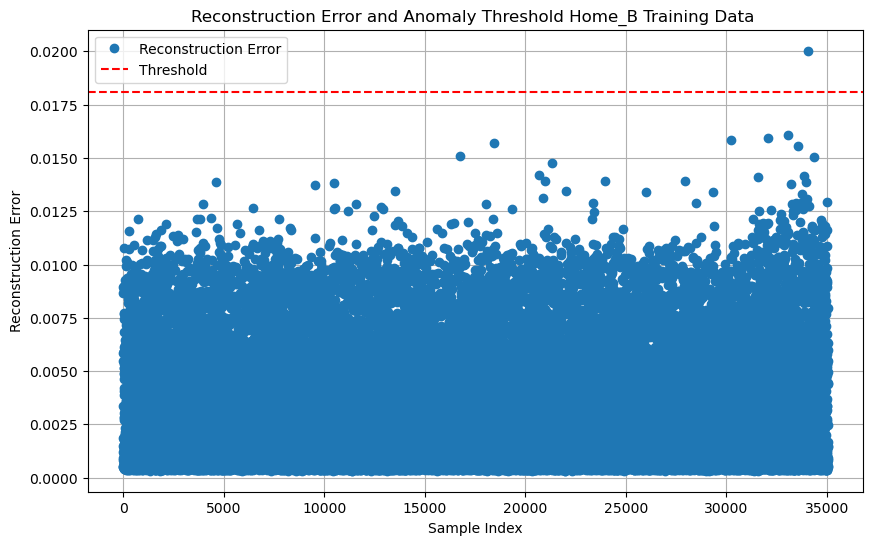

In [85]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (13 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold Home_B Training Data ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Training.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Training.eps',bbox_inches='tight')
plt.show()


In [86]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)
#################################################

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

9/9 [==============================] - 0s 2ms/step


C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Threshold saved at: 0.018085239919588617
Anomalous Data Indices:
[  0   2   6  10  12  21  28  33  39  40  43  44  45  50  55  74  77  91
  97  98 111 116 117 123 128 132 150 152 158 161 190 199 208 211 214 220
 233 234 237 250 253 277 281 282]


In [87]:
# test_reconstruction_error

In [88]:
# y_test

In [89]:
# anomalies

In [90]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.6458333333333334
Precision: 0.9545454545454546
Recall: 0.29577464788732394
TNR: 0.9863013698630136
FPR: 0.0136986301369863
FNR: 0.704225352112676
F1 Score: 0.45161290322580644
ROC AUC: 0.7889735674319891


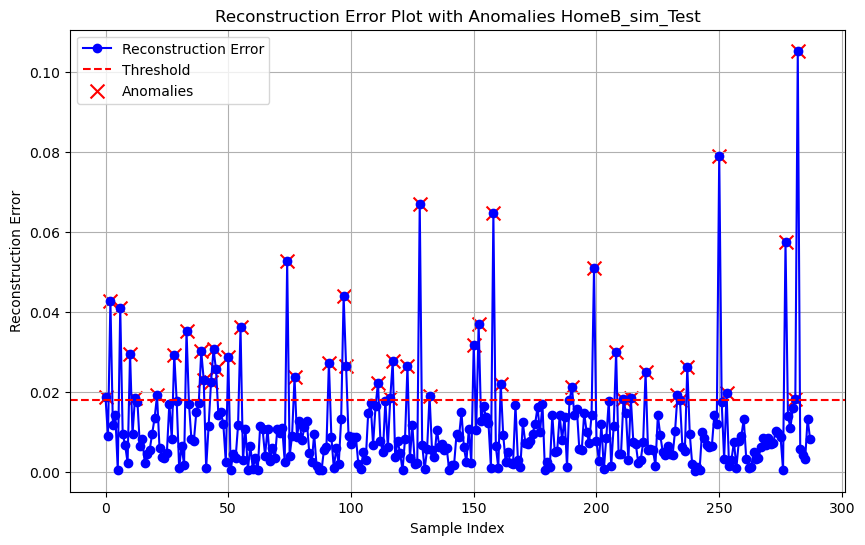

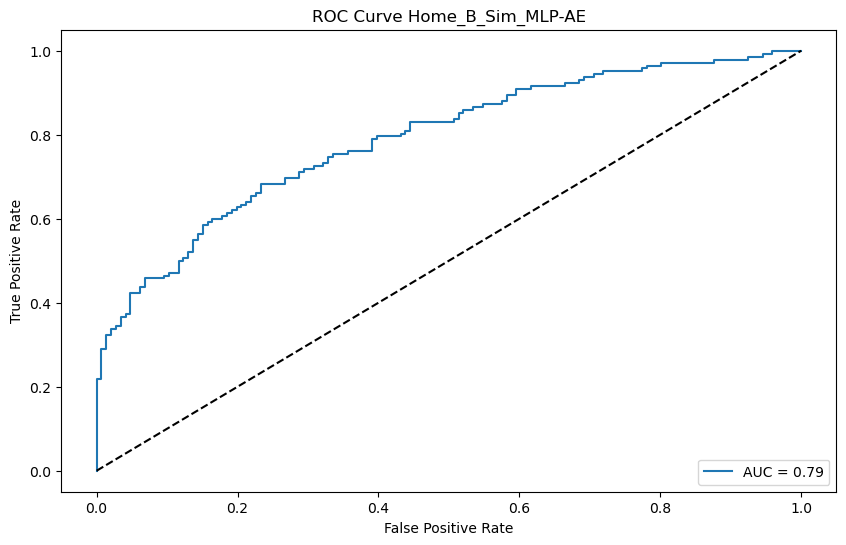

In [91]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_sim_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_B_Sim_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 2ms/step
Threshold saved at: 0.018085239919588617
Anomalous Data Indices:
[   28   146   170   186   204   259   335   356   407   420   441   443
   456   544   569   595   640   645   651   686   733   744   754   755
   764   783   786   816   851   878   882   961   985   987  1006  1035
  1062  1109  1165  1177  1213  1236  1260  1274  1343  1344  1384  1391
  1408  1430  1447  1455  1537  1565  1599  1763  1765  1769  1780  1789
  1793  1841  1851  1906  1988  1998  2030  2035  2087  2117  2141  2149
  2170  2181  2200  2202  2270  2323  2327  2448  2547  2555  2597  2613
  2636  2644  2734  2747  2749  2769  2790  2801  2901  2939  3053  3097
  3129  3132  3137  3156  3170  3182  3212  3259  3266  3294  3296  3328
  3373  3392  3440  3445  3609  3616  3646  3685  3718  3750  3805  3858
  3875  3968  3978  4039  4042  4064  4083  4093  4125  4347  4350  4417
  4440  4479  4586  4606  4649  4653  4730  4794  4797  4824  4835  4858
  48

In [93]:
test_reconstruction_error

array([0.01263573, 0.00724215, 0.00493999, ..., 0.00187441, 0.00639898,
       0.01215627])

In [94]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [95]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5150114155251142
Precision: 0.7476459510357816
Recall: 0.045319634703196346
TNR: 0.984703196347032
FPR: 0.015296803652968037
FNR: 0.9546803652968037
F1 Score: 0.08545904638897858
ROC AUC: 0.5970066173557682


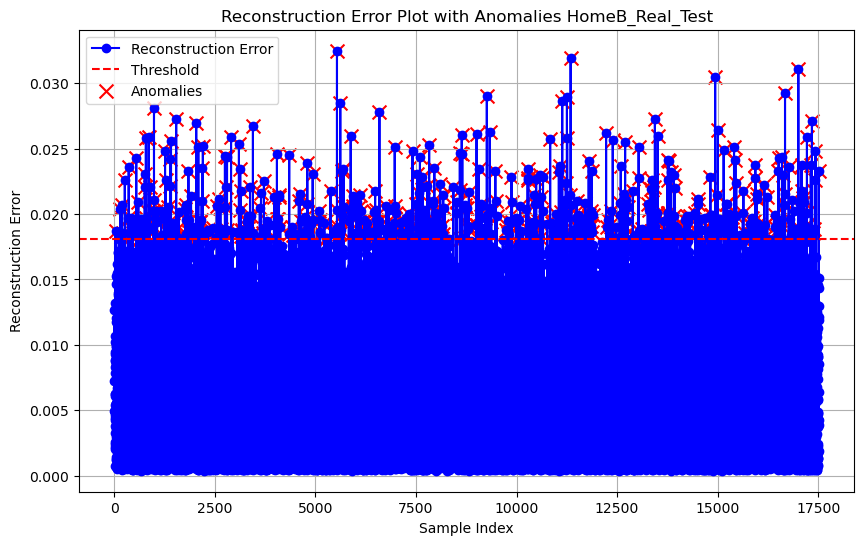

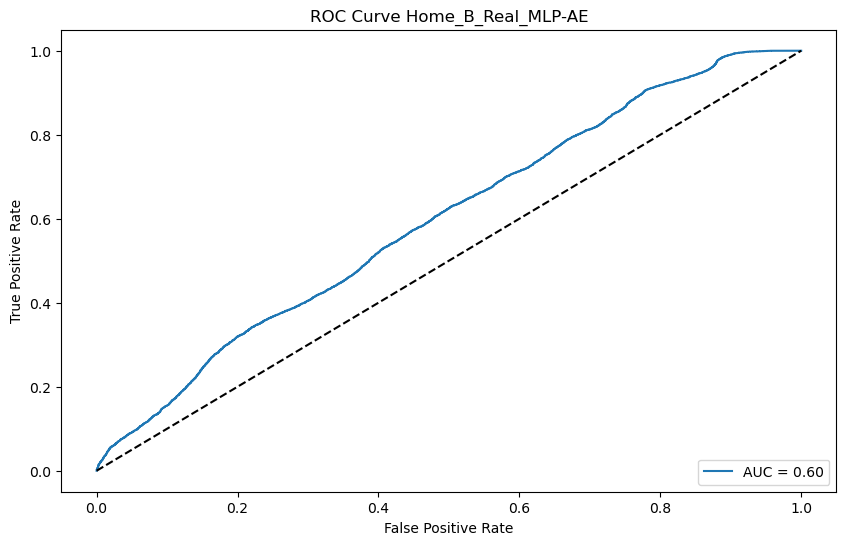

In [96]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Real_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_real.eps',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Home_B_Real_MLP-AE')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_real.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_real.eps',bbox_inches='tight')
plt.show()


### Model - 2 for Home B (Simulated and Real Test Set)
#### Implementing hidden-dim layers

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [60]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 64
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# ... rest of the code ...

############################################################################

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 5s 4ms/step - loss: 0.0217 - val_loss: 0.0122
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0099 - val_loss: 0.0090
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0081 - val_loss: 0.0077
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0071 - val_loss: 0.0070
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0064 - val_loss: 0.0066
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0061 - val_loss: 0.0063
Epoch 8/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0060 - val_loss: 0.0063
Epoch 9/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0057 - val_lo

986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 82/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 83/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 84/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 85/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 86/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 87/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 88/100
986/986 [==============================] - 3s 4ms/step - loss: 0.0043 - val_loss: 0.0047
Epoch 89/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 90/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0043 - val_loss: 

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_12 (Dense)            (None, 32)                44192     
                                                                 
 dense_13 (Dense)            (None, 128)               4224      
                                                                 
 dense_14 (Dense)            (None, 64)                8256      
                                                                 
 dense_15 (Dense)            (None, 128)               8320      
                                                                 
 dense_16 (Dense)            (None, 1380)              178020    
                                                                 
Total params: 243,012
Trainable params: 243,012
Non-trainab

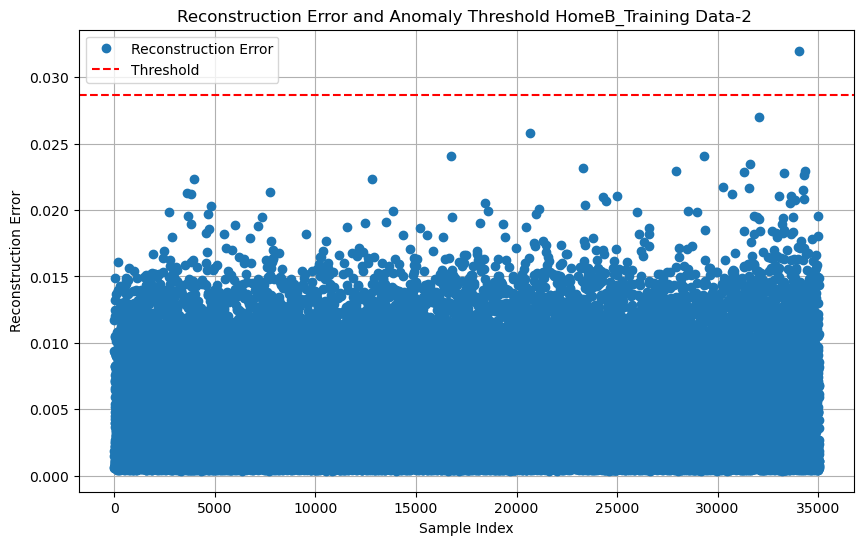

In [61]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (13 * mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold HomeB_Training Data-2 ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Training-2.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_rec-err_thr.eps',bbox_inches='tight')
plt.show()


In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


9/9 [==============================] - 0s 2ms/step
Threshold saved at: 0.028641260944714662
Anomalous Data Indices:
[  0   2   4   6  10  12  13  20  21  26  28  33  34  38  39  40  43  44
  45  47  50  55  57  74  77  82  91  97  98 108 111 116 117 123 128 132
 150 152 154 158 161 167 176 178 185 189 190 199 202 208 211 212 214 220
 234 237 250 251 253 277 280 281 282]


In [63]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.6701388888888888
Precision: 0.873015873015873
Recall: 0.3873239436619718
TNR: 0.9452054794520548
FPR: 0.0547945205479452
FNR: 0.6126760563380281
F1 Score: 0.5365853658536585
ROC AUC: 0.7680397453212426


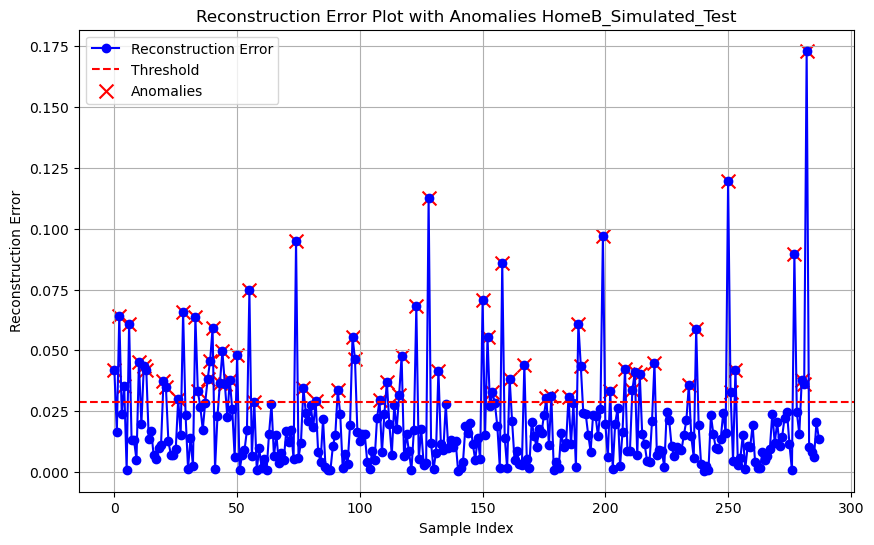

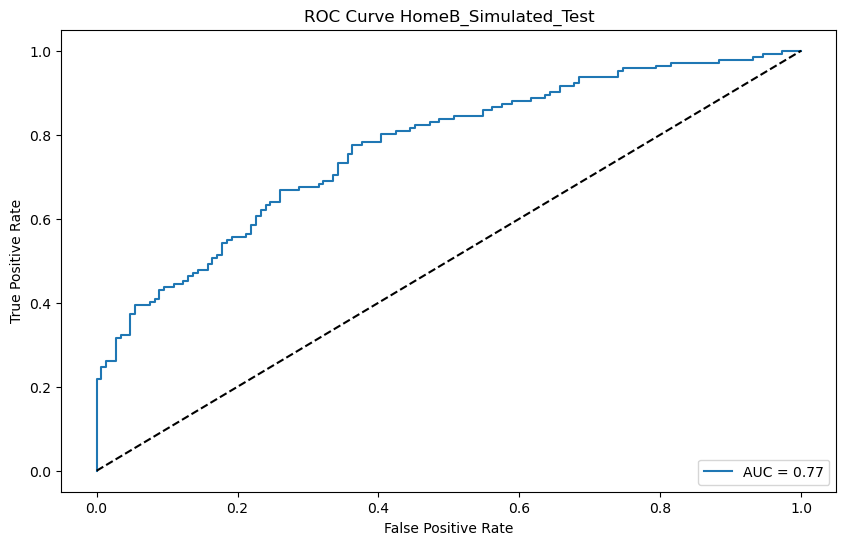

In [64]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Simulated_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim-2.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeB_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [65]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
# y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
# y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)

# Convert anomalies to binary format
#anomalies_binary = np.where(anomalies, 1, 0)

C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 1ms/step
Threshold saved at: 0.028641260944714662
Anomalous Data Indices:
[    0     9    49 ... 17510 17511 17513]


In [66]:
test_reconstruction_error

array([0.02969997, 0.01331753, 0.00835661, ..., 0.00388687, 0.01263874,
       0.02720887])

In [67]:
y_test

array([1, 0, 0, ..., 1, 1, 1], dtype=int64)

In [68]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5304223744292238
Precision: 0.6447582835415535
Recall: 0.13550228310502282
TNR: 0.9253424657534246
FPR: 0.07465753424657534
FNR: 0.8644977168949771
F1 Score: 0.22394113762852563
ROC AUC: 0.5948175470694939


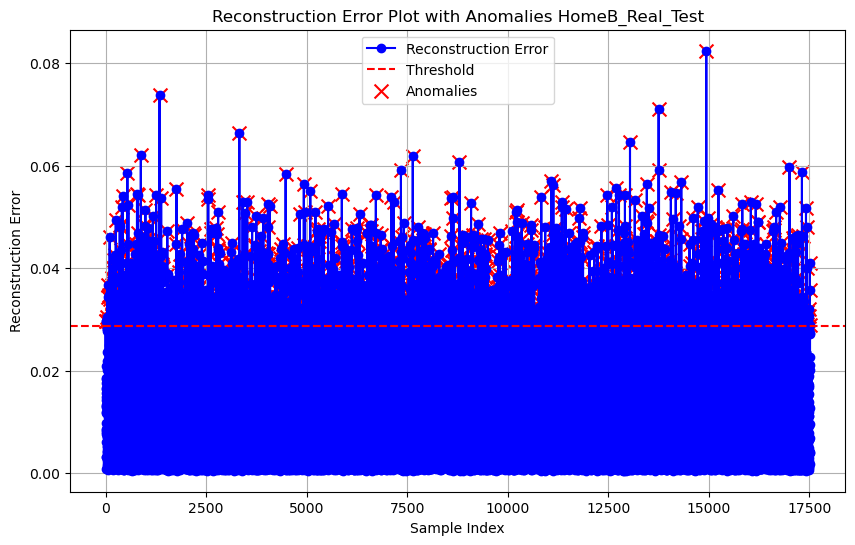

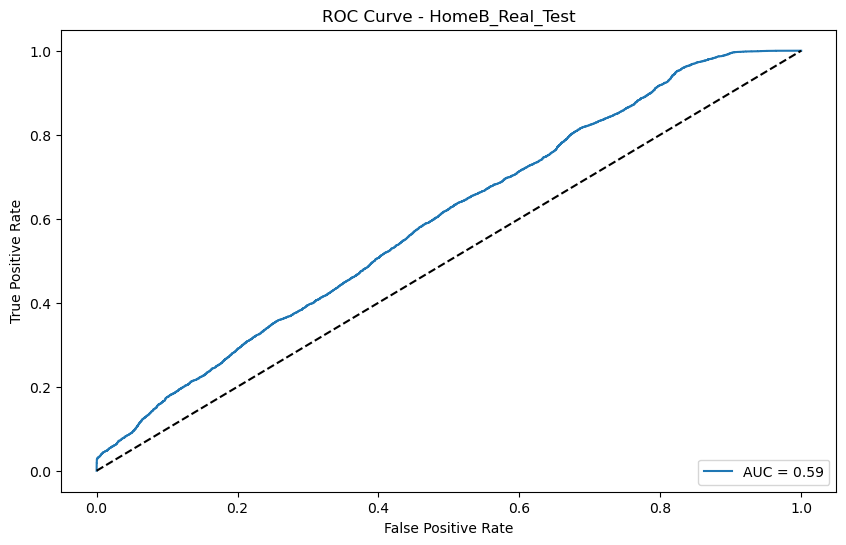

In [69]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Real_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_real-2.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Anomalies_real.eps',bbox_inches='tight')
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - HomeB_Real_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_real-2.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_real.eps',bbox_inches='tight')
plt.show()


### Model - 2 for Home B (Simulated and Real Test Set)¶
#### Implementing hidden-dim layers: Latent 32, 64 and 128

In [112]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [113]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 128
hidden_dim = 64  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=64,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
493/493 [==============================] - 8s 13ms/step - loss: 0.0365 - val_loss: 0.0355
Epoch 2/100
493/493 [==============================] - 6s 11ms/step - loss: 0.0347 - val_loss: 0.0355
Epoch 3/100
493/493 [==============================] - 6s 11ms/step - loss: 0.0308 - val_loss: 0.0169
Epoch 4/100
493/493 [==============================] - 5s 10ms/step - loss: 0.0120 - val_loss: 0.0095
Epoch 5/100
493/493 [==============================] - 6s 12ms/step - loss: 0.0080 - val_loss: 0.0073
Epoch 6/100
493/493 [==============================] - 5s 11ms/step - loss: 0.0066 - val_loss: 0.0063
Epoch 7/100
493/493 [==============================] - 6s 13ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 8/100
493/493 [==============================] - 6s 12ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 9/100
493/493 [==============================] - 6s 11ms/step - loss: 0.0048 - val_loss: 0.0049
Epoch 10/100
493/493 [==============================] - 5s 10ms/step - loss: 0.004

Epoch 81/100
493/493 [==============================] - 5s 11ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 82/100
493/493 [==============================] - 4s 9ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 83/100
493/493 [==============================] - 5s 9ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 84/100
493/493 [==============================] - 4s 9ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 85/100
493/493 [==============================] - 4s 9ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 86/100
493/493 [==============================] - 5s 9ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 87/100
493/493 [==============================] - 5s 11ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 88/100
493/493 [==============================] - 5s 10ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 89/100
493/493 [==============================] - 4s 7ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 90/100
493/493 [==============================] - 5s 10ms/step - loss: 0.

Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_31 (Dense)            (None, 64)                88384     
                                                                 
 dense_32 (Dense)            (None, 256)               16640     
                                                                 
 dense_33 (Dense)            (None, 128)               32896     
                                                                 
 dense_34 (Dense)            (None, 256)               33024     
                                                                 
 dense_35 (Dense)            (None, 1380)              354660    
                                                                 
Total params: 525,604
Trainable params: 525,604
Non-trainab

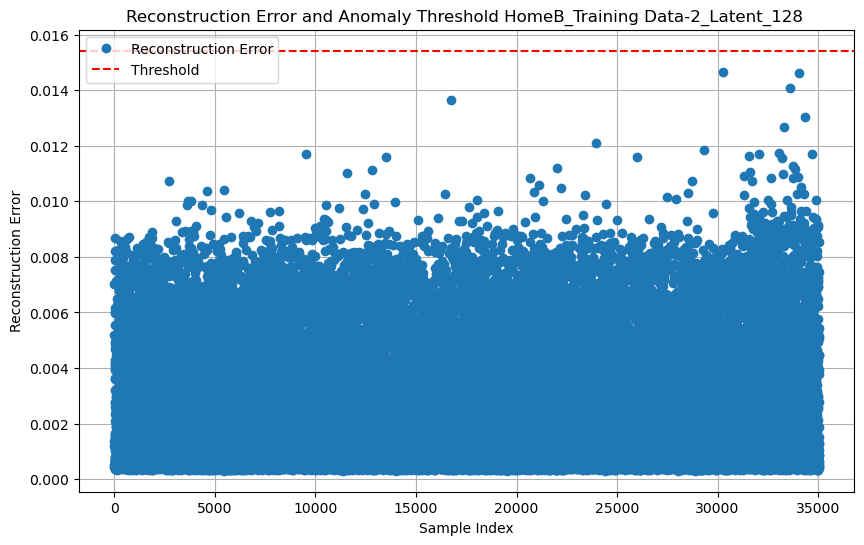

In [127]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (12 *mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold HomeB_Training Data-2_Latent_128 ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Training-2_Latent_128.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_rec-err_thr.eps',bbox_inches='tight')
plt.show()

In [128]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


9/9 [==============================] - 0s 4ms/step
Threshold saved at: 0.015419570356519308
Anomalous Data Indices:
[  0   2   4   6  10  12  13  21  28  33  34  37  38  39  40  43  44  45
  46  47  50  55  57  74  77  79  91  96  97  98 107 111 114 117 123 128
 135 145 150 152 153 154 155 158 161 167 176 178 189 190 191 195 198 199
 202 205 208 211 214 220 234 237 248 250 251 253 260 277 278 280 281 282]


In [129]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.6597222222222222
Precision: 0.8055555555555556
Recall: 0.4084507042253521
TNR: 0.9041095890410958
FPR: 0.0958904109589041
FNR: 0.5915492957746479
F1 Score: 0.5420560747663551
ROC AUC: 0.7797607563187343


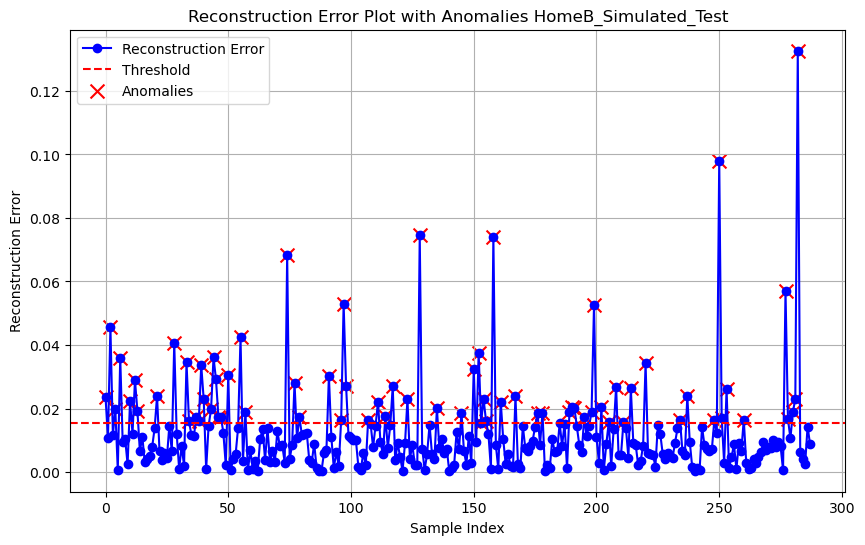

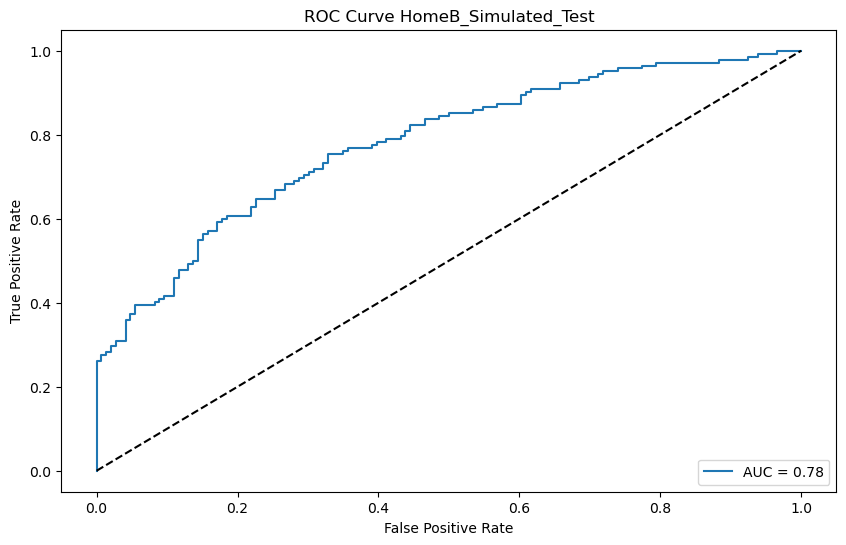

In [130]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Simulated_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim-2_Latent_128.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeB_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim_Latent_128.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [131]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\2449011032.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\2449011032.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 2s 3ms/step
Threshold saved at: 0.015419570356519308
Anomalous Data Indices:
[    9    28    46 ... 17498 17511 17513]


In [132]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5198059360730594
Precision: 0.5906952430737062
Recall: 0.12899543378995434
TNR: 0.9106164383561643
FPR: 0.08938356164383561
FNR: 0.8710045662100456
F1 Score: 0.2117492738686405
ROC AUC: 0.588270925856425


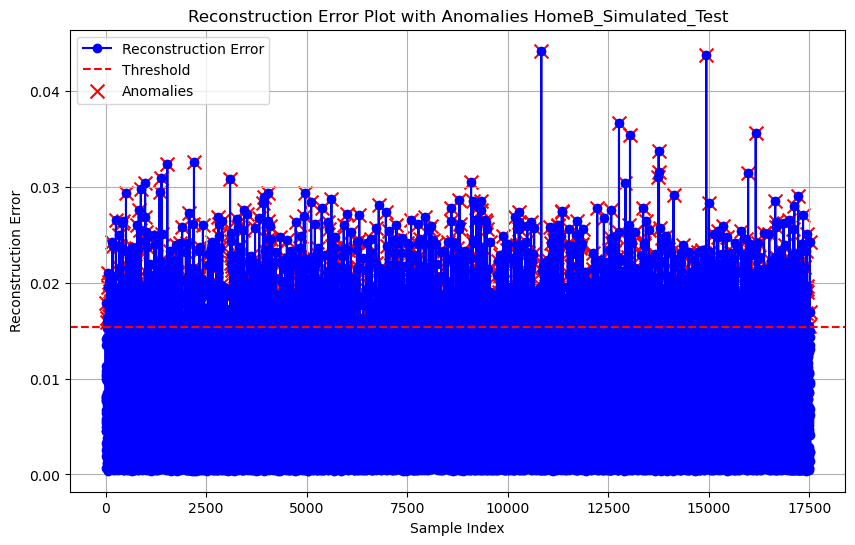

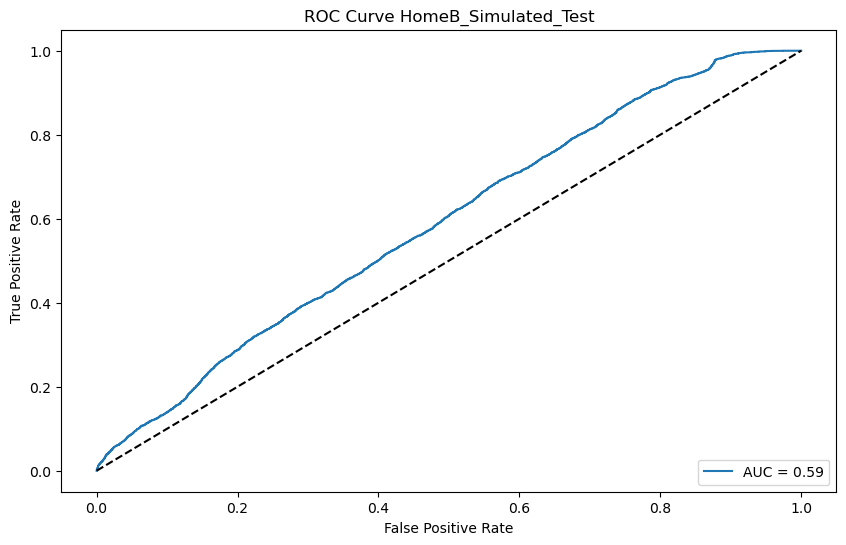

In [133]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Simulated_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim-2_Latent_128.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeB_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim_Latent_128.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Load and preprocess data
data_path = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_df = pd.read_csv(data_path)

# Extract features (X) and target labels (y) from the loaded data
X = data_df.drop(columns=["Label"])  # Drop the label column
y = data_df["Label"]

# Split the data into training and test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing - Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X)
#X_test_scaled = scaler.transform(X_test)

# Print the extracted values of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train_scaled shape:", X_train.shape)
#print("y_train shape:", y_train.shape)


X shape: (35040, 1380)
y shape: (35040,)
X_train_scaled shape: (35040, 1380)


In [135]:
# Define the autoencoder model with deep layers
input_dim = X_train_scaled.shape[1]
encoding_dim = 32
hidden_dim = 32  # This is the variable you want to use

input_layer = Input(shape=(input_dim,))
encoder_hidden_layer = Dense(hidden_dim, activation='relu')(input_layer)  # Hidden layer
encoder_layer1 = Dense(encoding_dim * 2, activation='relu')(encoder_hidden_layer)
encoder_layer2 = Dense(encoding_dim, activation='relu')(encoder_layer1)
decoder_layer2 = Dense(encoding_dim * 2, activation='relu')(encoder_layer2)
decoder_layer1 = Dense(input_dim, activation='sigmoid')(decoder_layer2)

autoencoder = Model(input_layer, decoder_layer1)
autoencoder.compile(optimizer='adam', loss='mse')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the autoencoder on the training set
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_split=0.1,  # Using a portion of training data for validation
                callbacks=[early_stopping])  # Adding the early stopping callback


Epoch 1/100
986/986 [==============================] - 7s 5ms/step - loss: 0.0221 - val_loss: 0.0137
Epoch 2/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0117 - val_loss: 0.0109
Epoch 3/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0098 - val_loss: 0.0096
Epoch 4/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 5/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0082 - val_loss: 0.0084
Epoch 6/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0077 - val_loss: 0.0078
Epoch 7/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0074 - val_loss: 0.0076
Epoch 8/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0071 - val_loss: 0.0073
Epoch 9/100
986/986 [==============================] - 5s 5ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 10/100
986/986 [==============================] - 4s 4ms/step - loss: 0.0068 - val_lo

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 1380)]            0         
                                                                 
 dense_36 (Dense)            (None, 32)                44192     
                                                                 
 dense_37 (Dense)            (None, 64)                2112      
                                                                 
 dense_38 (Dense)            (None, 32)                2080      
                                                                 
 dense_39 (Dense)            (None, 64)                2112      
                                                                 
 dense_40 (Dense)            (None, 1380)              89700     
                                                                 
Total params: 140,196
Trainable params: 140,196
Non-trainab

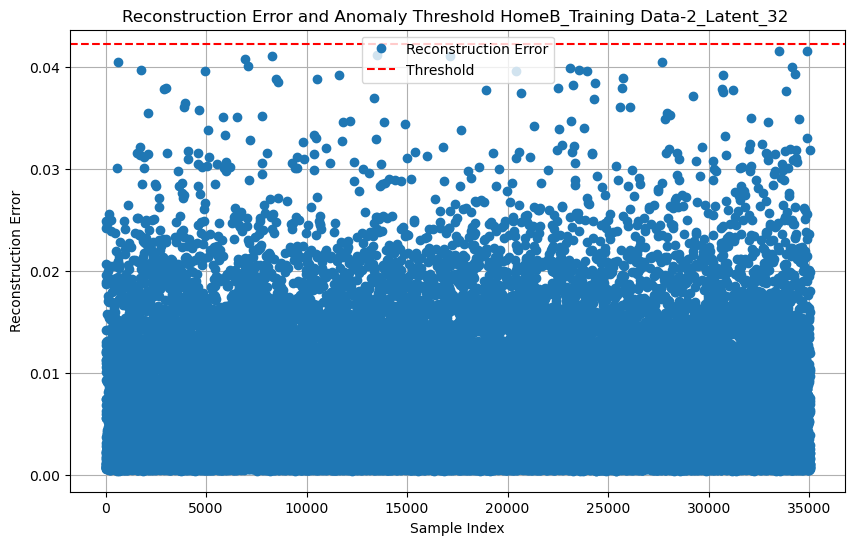

In [139]:
# Print the model summary
autoencoder.summary()

# Calculate reconstruction error for test data
train_predictions = autoencoder.predict(X_train_scaled)
reconstruction_error = np.mean(np.square(X_train_scaled - train_predictions), axis=1)

# Print reconstruction errors
print("Reconstruction Errors:")
print(reconstruction_error)

# Calculate threshold using Median Absolute Deviation (MAD)
median = np.median(reconstruction_error)
mad = np.median(np.abs(reconstruction_error - median))
threshold = median + (17 *mad)  # Adjust the multiplier as needed

print("Threshold:", threshold)

# Print and save the trained autoencoder model
model_path = "trained_autoencoder_model.h5"
autoencoder.save(model_path)
print("Model saved at:", model_path)

# Save the threshold
threshold_path = "trained_threshold.npy"
np.save(threshold_path, threshold)
print("Threshold saved at:", threshold_path)

# Visualize the reconstruction error and threshold
plt.figure(figsize=(10, 6))
plt.plot(reconstruction_error, marker='o', linestyle='', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error and Anomaly Threshold HomeB_Training Data-2_Latent_32 ')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_Training-2_Latent_32.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_rec-err_thr.eps',bbox_inches='tight')
plt.show()

In [140]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_sim_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\3266521010.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


9/9 [==============================] - 0s 2ms/step
Threshold saved at: 0.04220373496390684
Anomalous Data Indices:
[  2   6  13  28  33  39  44  45  50  55  74  77  97  98 123 128 150 152
 158 199 237 250 277 282]


In [141]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.5833333333333334
Precision: 0.9583333333333334
Recall: 0.1619718309859155
TNR: 0.9931506849315068
FPR: 0.00684931506849315
FNR: 0.8380281690140845
F1 Score: 0.2771084337349397
ROC AUC: 0.7715608720818058


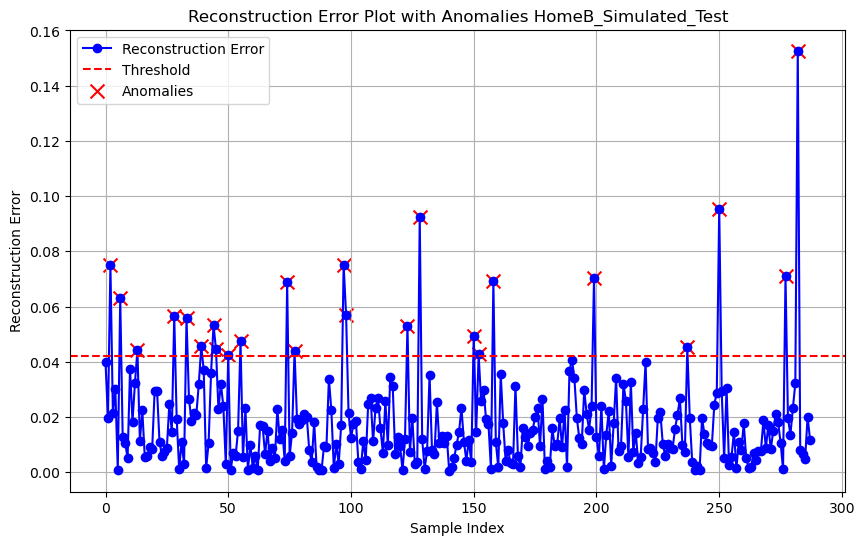

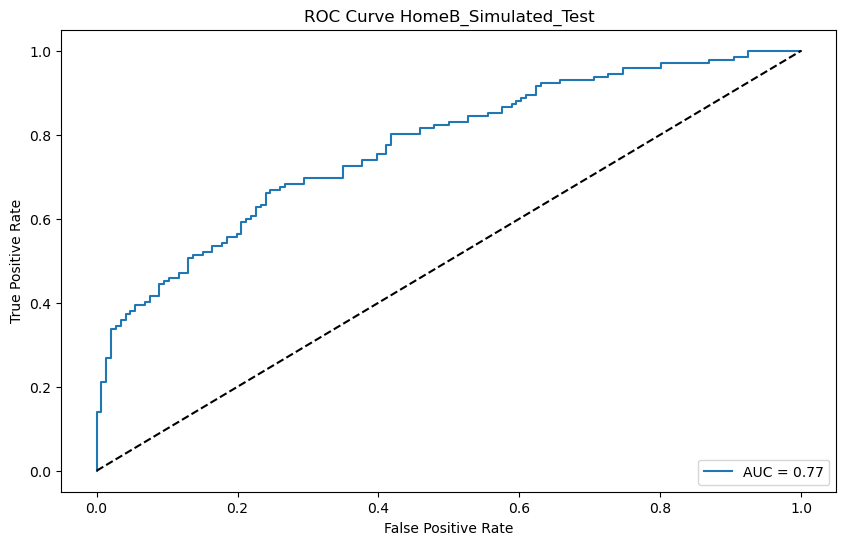

In [142]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Simulated_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim-2_Latent_32.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeB_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim_Latent_32.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()


In [143]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
    f1_score, roc_curve, roc_auc_score, confusion_matrix
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Load data paths
data_path_train = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_unsupervise_train.csv"
data_path_test = "C:/Users/olufe/projects/Journal/dataset/psa_journal_home_B_real_test.csv"

# Load train and test data
train_data = pd.read_csv(data_path_train)
test_data = pd.read_csv(data_path_test)

# Drop the last column to extract features (X) and labels (y) from both datasets
X_train = train_data.drop(columns=['Label']).values
y_train = train_data['Label'].values
X_test = test_data.drop(columns=['Label']).values
y_test = test_data['Label'].values

# Convert labels to binary format (assuming 'Anomaly' is the anomaly class)
y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
y_test_binary = np.where(y_test == 'Anomaly', 1, 0)

# Data preprocessing
# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Load the trained autoencoder model
autoencoder = load_model("trained_autoencoder_model.h5")

# Calculate reconstruction error for test data
test_predictions = autoencoder.predict(X_test_scaled)
test_reconstruction_error = np.mean(np.square(X_test_scaled - test_predictions), axis=1)

# Load the saved threshold
threshold = np.load("trained_threshold.npy")
print("Threshold saved at:", threshold)

# Classify anomalies based on the threshold
anomalies = test_reconstruction_error > threshold

# Print the indices of anomalous data
print("Anomalous Data Indices:")
anomalous_indices = np.where(anomalies)[0]
print(anomalous_indices)


C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\2449011032.py:24: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_train_binary = np.where(y_train == 'Anomaly', 1, 0)
C:\Users\olufe\AppData\Local\Temp\ipykernel_26548\2449011032.py:25: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  y_test_binary = np.where(y_test == 'Anomaly', 1, 0)
C:\Users\olufe\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


548/548 [==============================] - 1s 2ms/step
Threshold saved at: 0.04220373496390684
Anomalous Data Indices:
[  259   356   427   569   755   800   985   987  1260  1344  1537  1765
  1979  2547  2801  2901  3097  3129  3137  3328  3409  3445  4038  4931
  5024  5110  5114  5220  5375  5535  5617  5668  5697  5829  6225  6251
  6514  6719  6722  6970  6971  7536  7598  7640  7749  7827  8131  8177
  8466  8780  9217  9261  9332  9429  9473  9482 10243 10348 10582 10589
 10836 10934 11052 11083 11196 11224 11253 11345 11494 11524 11541 11561
 11865 12392 12477 12768 12930 12991 13042 13369 13685 13763 13779 13927
 13928 14105 14179 14256 14939 15006 15135 15235 15346 15443 15834 15979
 16046 16168 16231 16384 16668 16911 17007 17221 17317 17345 17513]


In [144]:
# Evaluate performance metrics
accuracy = accuracy_score(y_test, anomalies)
precision = precision_score(y_test, anomalies)
recall = recall_score(y_test, anomalies)
conf_matrix = confusion_matrix(y_test, anomalies)

Accuracy: 0.503824200913242
Precision: 0.8130841121495327
Recall: 0.00993150684931507
TNR: 0.997716894977169
FPR: 0.00228310502283105
FNR: 0.9900684931506849
F1 Score: 0.01962332243148754
ROC AUC: 0.6052171295427535


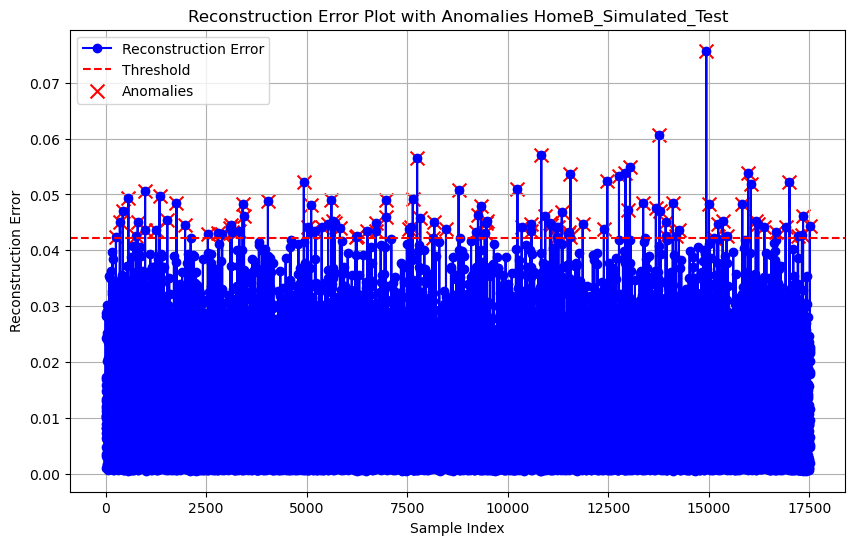

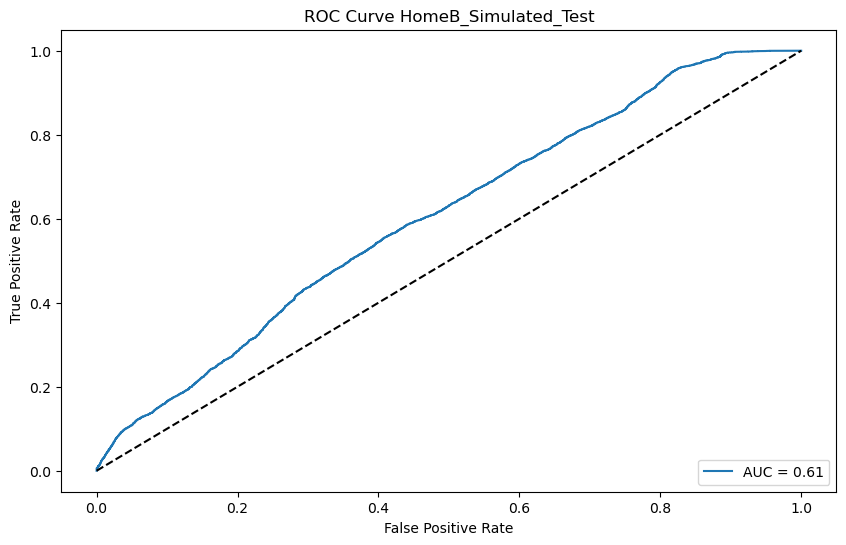

In [145]:
# Calculate True Negative Rate (TNR), False Positive Rate (FPR), False Negative Rate (FNR)
tnr = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fpr = conf_matrix[0, 1] / (conf_matrix[0, 0] + conf_matrix[0, 1])
fnr = conf_matrix[1, 0] / (conf_matrix[1, 0] + conf_matrix[1, 1])

f1 = f1_score(y_test, anomalies)
roc_auc = roc_auc_score(y_test, test_reconstruction_error)
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, test_reconstruction_error)

# Print performance metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("TNR:", tnr)
print("FPR:", fpr)
print("FNR:", fnr)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)

# Plot reconstruction error with anomalous points highlighted
plt.figure(figsize=(10, 6))
plt.plot(test_reconstruction_error, marker='o', linestyle='-', color='b', label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')

# Highlight anomalous points with unique color and marker
plt.scatter(anomalous_indices, test_reconstruction_error[anomalous_indices],
            color='red', marker='x', s=100, label='Anomalies')

plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error Plot with Anomalies HomeB_Simulated_Test')
plt.legend()
plt.grid()
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim-2_Latent_32.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_anomalies_sim.eps',bbox_inches='tight')
plt.show()


# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr_curve, tpr_curve, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve HomeB_Simulated_Test')
plt.legend(loc='lower right')
plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim_Latent_32.png',bbox_inches='tight')
#plt.savefig(r'C:\Users\olufe\projects\Journal\Diagrams\Home_B\mlp-B_ROC_sim.eps',bbox_inches='tight')
plt.show()
